1. Train / Test Split

In [46]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("df_transformer_ready.csv")

X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label_encoded"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_encoded"]
)

print(len(X_train), len(X_test))

17138 4285


In [47]:
# -- Label mapping — adjust names to match your actual dataset labels
label_map = {0: "low", 1: "medium", 2: "high"}
inverse_label_map = {v: k for k, v in label_map.items()}

print("Label mapping:", label_map)

Label mapping: {0: 'low', 1: 'medium', 2: 'high'}


In [ ]:
from huggingface_hub import login

login("your_huggingface_token_here")


2. Load MentalBERT Tokenizer

In [49]:
from transformers import AutoTokenizer

model_name = "mental/mental-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

Convert to HuggingFace Dataset

In [50]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

Apply Tokenization

In [51]:
train_dataset = train_dataset.map(
    lambda x: tokenizer(x["text"], truncation=True, padding="max_length", max_length=128),
    batched=True
)

test_dataset = test_dataset.map(
    lambda x: tokenizer(x["text"], truncation=True, padding="max_length", max_length=128),
    batched=True
)

Map: 100%|██████████| 4285/4285 [00:00<00:00, 5243.03 examples/s]


Load MentalBERT Model

In [52]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10468.49it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different tas

Training Setup

In [53]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Using device:", device)

Using device: cuda


In [54]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,
    weight_decay=0.01,

    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", 
    greater_is_better=True
)

Trainer

In [55]:
from transformers import Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, predictions),
        "f1_macro":  f1_score(labels, predictions, average="macro"),
        "precision": precision_score(labels, predictions, average="macro", zero_division=0),
        "recall":    recall_score(labels, predictions, average="macro", zero_division=0),
    }
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

TRAIN THE MODEL

In [56]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.441042,0.513048,0.819137,0.817990,0.827784,0.817490
2,0.296155,0.516303,0.854376,0.853520,0.860584,0.850825
3,0.176190,0.648627,0.854609,0.853938,0.855775,0.852807


Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.86s/it]


TrainOutput(global_step=6429, training_loss=0.3130161738132388, metrics={'train_runtime': 4333.0701, 'train_samples_per_second': 11.865, 'train_steps_per_second': 1.484, 'total_flos': 3381928314766848.0, 'train_loss': 0.3130161738132388, 'epoch': 3.0})

In [57]:
# Save fine-tuned model and tokenizer
trainer.save_model("./mentalbert-finetuned")
tokenizer.save_pretrained("./mentalbert-finetuned")
print("✅ Model and tokenizer saved to ./mentalbert-finetuned")

Writing model shards: 100%|██████████| 1/1 [00:12<00:00, 12.19s/it]

✅ Model and tokenizer saved to ./mentalbert-finetuned


EVALUATE MODEL

In [58]:
results = trainer.evaluate()
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision,Recall
0.176190,0.648627,3,0.854609,0.853938,0.855775,0.852807


{'eval_loss': 0.6486268639564514, 'eval_accuracy': 0.8546091015169195, 'eval_f1_macro': 0.8539380434377105, 'eval_precision': 0.8557751381702358, 'eval_recall': 0.8528067971327289}


FINAL PREDICTIONS

In [59]:
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

In [60]:
from sklearn.metrics import classification_report

target_names = [label_map[i] for i in sorted(label_map.keys())]
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

         low       0.84      0.82      0.83      1352
      medium       0.88      0.85      0.86      1358
        high       0.84      0.89      0.86      1575

    accuracy                           0.85      4285
   macro avg       0.86      0.85      0.85      4285
weighted avg       0.86      0.85      0.85      4285



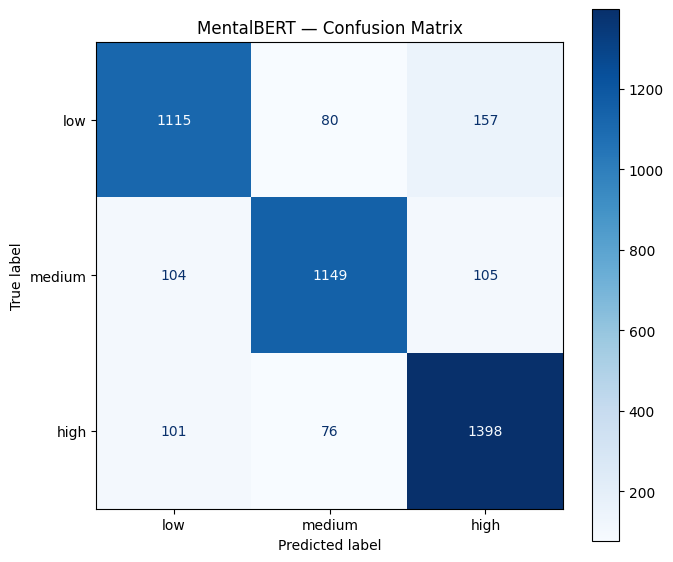

✅ Confusion matrix saved as confusion_matrix.png


In [61]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    cmap="Blues",
    ax=ax
)
ax.set_title("MentalBERT — Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved as confusion_matrix.png")

In [62]:
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model="./mentalbert-finetuned",
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# Test on sample sentences
test_sentences = [
    "I feel completely hopeless and can't get out of bed.",
    "I'm so anxious about everything, my heart is racing.",
    "I had a great day and feel really good about life.",
]

for sentence in test_sentences:
    result = clf(sentence)[0]
    label_idx = int(result["label"].split("_")[-1])
    print(f"Text   : {sentence}")
    print(f"Label  : {label_map[label_idx]} | Confidence: {result['score']:.4f}")
    print("-" * 60)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4848.88it/s]


Text   : I feel completely hopeless and can't get out of bed.
Label  : high | Confidence: 0.9995
------------------------------------------------------------
Text   : I'm so anxious about everything, my heart is racing.
Label  : high | Confidence: 0.9991
------------------------------------------------------------
Text   : I had a great day and feel really good about life.
Label  : low | Confidence: 0.9986
------------------------------------------------------------
